# Image augmentation

In [ ]:
# ! pip install albumentations opencv-python numpy
import cv2
import numpy as np
import albumentations as A
import os

def load_yolo_annotations(txt_path):
    """Load YOLO annotations from a .txt file."""
    boxes = []
    with open(txt_path, "r") as f:
        for line in f.readlines():
            values = line.strip().split()
            class_id = int(values[0])
            x_center, y_center, width, height = map(float, values[1:])
            boxes.append([x_center, y_center, width, height, class_id])
    return boxes

def save_yolo_annotations(txt_path, boxes):
    """Save YOLO annotations to a .txt file."""
    with open(txt_path, "w") as f:
        for box in boxes:
            f.write(f"{int(box[4])} {box[0]} {box[1]} {box[2]} {box[3]}\n")

def augment_image(image, bboxes):
    """Perform augmentations while skipping invalid ones."""
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Affine(scale=(0.95, 1.05), translate_percent=(-0.05, 0.05), rotate=(-10, 10), p=0.5)
    ], bbox_params=A.BboxParams(format='yolo', label_fields=[]))

    try:
        transformed = transform(image=image, bboxes=[b[:4] for b in bboxes])

        # Check if any bounding box is invalid
        for bbox in transformed["bboxes"]:
            if any(coord < 0 or coord > 1 for coord in bbox):
                print("Skipping augmentation due to invalid bbox:", bbox)
                return image, bboxes

        return transformed["image"], transformed["bboxes"]

    except Exception as e:
        print("Error during augmentation:", e)
        return image, bboxes  # Skip and return original data

def augment_dataset(original_images_dir, original_labels_dir):
    """Augment dataset and save only the augmented images and labels."""
    image_files = [f for f in os.listdir(original_images_dir) if f.endswith(('.jpg', '.JPG'))]

    for img_file in image_files:
        img_path = os.path.join(original_images_dir, img_file)
        label_path = os.path.join(original_labels_dir, img_file.replace('.jpg', '.txt').replace('.JPG', '.txt'))
        
        if not os.path.exists(label_path):
            continue

        image = cv2.imread(img_path)

        # Load YOLO bounding boxes (normalized values)
        boxes = load_yolo_annotations(label_path)

        # Generate and save augmented image and annotations
        augmented_image, augmented_boxes = augment_image(image, boxes)

        # Preserve original class labels
        aug_boxes = [b + [boxes[i][4]] for i, b in enumerate(augmented_boxes)]

        # Save augmented image and label
        aug_img_name = f"aug_{img_file}"
        aug_label_name = f"aug_{img_file.replace('.jpg', '.txt').replace('.JPG', '.txt')}"
        cv2.imwrite(os.path.join(original_images_dir, aug_img_name), augmented_image)
        save_yolo_annotations(os.path.join(original_labels_dir, aug_label_name), aug_boxes)

# Define dataset directories
original_images_dir = "/home/aojwang/data/yolo_dataset/val/images"
original_labels_dir = "/home/aojwang/data/yolo_dataset/val/labels"

# Process and save the augmented dataset
augment_dataset(original_images_dir, original_labels_dir)

## Visualize augmented images

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# Define dataset directories
image_dir = "/home/aojwang/data/yolo_dataset/val/images"
label_dir = "/home/aojwang/data/yolo_dataset/val/labels"

# Dynamically list all images starting with "aug_"
augmented_images = [img for img in os.listdir(image_dir) if img.startswith("aug_")]

# Count total images and labels
total_images = len(os.listdir(image_dir))
total_labels = len(os.listdir(label_dir))
total_augmented = len(augmented_images)

print(f"Total Images: {total_images}")
print(f"Total Labels: {total_labels}")
print(f"Total Augmented Images: {total_augmented}")

# Choose a random augmented image for visualization
if total_augmented == 0:
    print("No augmented images found.")
else:
    random_image = random.choice(augmented_images)
    image_path = os.path.join(image_dir, random_image)
    
    # Handle different file extensions
    label_path = os.path.join(label_dir, random_image.rsplit(".", 1)[0] + ".txt")

    # Function to read YOLO annotations
    def read_yolo_annotations(txt_file):
        boxes = []
        if not os.path.exists(txt_file):
            print(f"Warning: Label file not found for {random_image}")
            return boxes
        with open(txt_file, "r") as f:
            for line in f:
                values = line.strip().split()
                class_id = int(values[0])
                x_center, y_center, width, height = map(float, values[1:])
                boxes.append((class_id, x_center, y_center, width, height))
        return boxes

    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display

    # Read bounding boxes
    bboxes = read_yolo_annotations(label_path)
    print(bboxes)
    h, w, _ = image.shape  # Get image dimensions

    # Draw bounding boxes
    for class_id, x_center, y_center, width, height in bboxes:
        x1 = int((x_center - width / 2) * w)
        y1 = int((y_center - height / 2) * h)
        x2 = int((x_center + width / 2) * w)
        y2 = int((y_center + height / 2) * h)

        # Draw rectangle and label
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 5)
        cv2.putText(image, f"Class {class_id}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    # Display the image with bounding boxes
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Augmented Image: {random_image}")
    plt.show()


# Train yolo model

In [ ]:
from ultralytics import YOLO 

model = YOLO("yolo11n.pt")
# results = model.train(data="/home/aojwang/data/yolo_dataset2/yolo.yaml", epochs=50, hsv_v=0.5, translate=0.2, scale=0.3, shear=10, erasing=0.2, batch=4, imgsz=640, project="runs/train",  name='yolo11_food_detection')
# model = YOLO("yolov8n.pt")
results = model.train(data="/home/aojwang/data/yolo_dataset/yolo.yaml",epochs=120,batch=4,imgsz=640,hsv_v=0.5,translate=0.2,scale=0.3,shear=10,erasing=0.2,flipud=0.3,fliplr=0.5,mosaic=1.0,mixup=0.5,box=0.05,cls=0.5,dfl=1.5,project="runs/train",name='yolo11_food_detection_improved')

New https://pypi.org/project/ultralytics/8.3.160 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/home/aojwang/data/yolo_dataset/yolo.yaml, epochs=120, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/train, name=yolo11_food_detection_improved7, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retin

train: Scanning /opt/dlami/nvme/aojwang/yolo_dataset/train/labels.cache... 9652 images, 640 backgrounds, 0 corrupt: 100%|██████████| 

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))



val: Scanning /opt/dlami/nvme/aojwang/yolo_dataset/val/labels.cache... 2758 images, 188 backgrounds, 0 corrupt: 100%|██████████| 2758


Plotting labels to runs/train/yolo11_food_detection_improved7/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: SGD(lr=0.01, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/train/yolo11_food_detection_improved7
Starting training for 120 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

IOPub message rate exceeded.09234      1.298      1.515         12        640:   4%|▍         | 100/2413 [00:24<08:10,  4.71it/s]
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 345/345 [01:35<00:00,  3.6


                   all       2758       4142      0.796      0.822      0.868      0.577

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     74/120      1.06G   0.009107      1.298      1.508         18        640: 100%|██████████| 2413/2413 [09:07<00:00,  4.40it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 345/345 [01:34<00:00,  3.6


                   all       2758       4142      0.808      0.807       0.87      0.581

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     75/120      1.06G    0.00915      1.309      1.513         14        640:  39%|███▉      | 947/2413 [03:36<04:06,  5.94it/s]  

## References
* https://github.com/ultralytics/ultralytics/issues/2789 *

# Label detection scatter plot

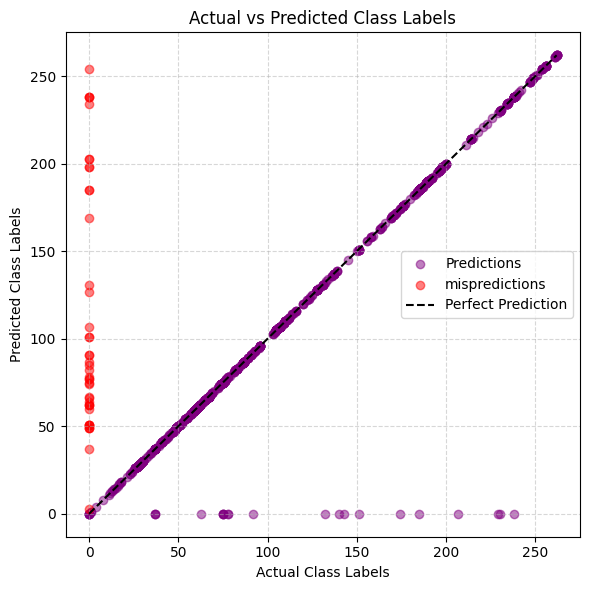

In [32]:
from ultralytics import YOLO
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Load the trained YOLO model
# model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/AUG3_food_detection2/weights/best.pt")
model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_detection_improved6/weights/best.pt")

# Load all image paths (case-insensitive JPG/JPEG)
image_paths = glob('/home/aojwang/data/y1_dataset2/val/images/*')
image_paths = [p for p in image_paths if p.lower().endswith(('.jpg'))]

actual_classes = [] # np.zeros(len(image_paths))
predicted_classes =  []  # np.zeros(len(image_paths))
misactual_classes = []
mispredicted_classes = []

for im_index, img_path in enumerate(image_paths):
    # Check for corresponding label
    label_path = img_path.replace('images', 'labels')
    label_path = os.path.splitext(label_path)[0] + '.txt'
    
    if not os.path.exists(label_path):
        continue  # skip image if no label
    actual_class = []
    with open(label_path, 'r') as f:
        lines = f.readlines()
        targets = [int(line.split()[0]) for line in lines]
        actual_class.extend(targets)
        #print("actual", targets)
    
    results = model(img_path, verbose=False)
    predicted_class = []
    for r in results:
        if len(r.boxes) > 0:
            preds = r.boxes.cls.cpu().numpy().astype(int)
            predicted_class.extend( [x.item() for x in preds])
    #print("predicted", predicted_class)
    for item in actual_class:
        if item in predicted_class:
            actual_classes.append(item)    # ground truth
            predicted_classes.append(item) # predicted, accurately
        else:
            actual_classes.append(item)   # ground truth
            predicted_classes.append(0)   # missing ground truth labels 
            
    for item in predicted_class:
        if item not in actual_class:
            mispredicted_classes.append(item) # predicted but not  ground truth
            misactual_classes.append(0)       # placeholder to help with plotting
    #break
    
# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(actual_classes, predicted_classes, alpha=0.5, color='purple', label='Predictions')
plt.scatter(misactual_classes, mispredicted_classes, alpha=0.5, color='red', label='mispredictions')

# Dotted y = x reference line
max_val = max(max(actual_classes), max(predicted_classes))
min_val = min(min(actual_classes), min(predicted_classes))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')

# Labels and title
plt.xlabel("Actual Class Labels")
plt.ylabel("Predicted Class Labels")
plt.title("Actual vs Predicted Class Labels")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

correct_predictions = sum([1 for a, p in zip(actual_classes, predicted_classes) if a == p and a != 0]) # excluding 
total_actuals = len([a for a in actual_classes if a != 0]) ## Total number of actual ground truth labels (excluding zeros
accuracy = correct_predictions / total_actuals if total_actuals > 0 else 0

# Filter out placeholders (assuming 0 is not a valid class)
filtered_actuals = [a for a, p in zip(actual_classes, predicted_classes) if a != 0 or p != 0]
filtered_preds = [p for a, p in zip(actual_classes, predicted_classes) if a != 0 or p != 0]

precision = precision_score(filtered_actuals, filtered_preds, average='macro', zero_division=0)
recall = recall_score(filtered_actuals, filtered_preds, average='macro', zero_division=0)
f1 = f1_score(filtered_actuals, filtered_preds, average='macro', zero_division=0)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")


Accuracy: 98.10%
Precision: 97.62%
Recall: 95.87%
F1 Score: 96.54%


In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Accuracy
accuracy = np.mean(np.array(actual_classes) == np.array(predicted_classes))

# Precision, Recall, F1
precision = precision_score(actual_classes, predicted_classes, average='macro', zero_division=0)
recall = recall_score(actual_classes, predicted_classes, average='macro', zero_division=0)
f1 = f1_score(actual_classes, predicted_classes, average='macro', zero_division=0)

print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall: {recall * 100:.2f}%")
print(f"F1 Score: {f1 * 100:.2f}%")


Accuracy: 98.02%
Precision: 97.75%
Recall: 96.26%
F1 Score: 96.64%


# Validate yolo model

In [26]:
from ultralytics import YOLO

# Load a model
model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_detection_improved6/weights/best.pt")

# Validate the model
metrics = model.val(data='/home/aojwang/data/y1_dataset2/v1.yaml', project='runs/val', save_json=True)

Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
YOLO11n summary (fused): 238 layers, 2,697,280 parameters, 0 gradients, 6.9 GFLOPs


val: Scanning /opt/dlami/nvme/aojwang/y1_dataset2/val/labels.cache... 718 images, 50 backgrounds, 0 corrupt: 100%|██████████| 718/718
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 45/45 [00:14<00:00,  3.15i


                   all        718       1113      0.908       0.92      0.959      0.767
                 Beans          6          6          1      0.904      0.995      0.749
          Orange Juice          2          2          1      0.734      0.995      0.623
           Apple juice          1          1      0.941          1      0.995      0.796
     Carbonated Sprite          1          1          1          0      0.995      0.697
             Olive Oil          1          1      0.911          1      0.995      0.895
       Sunflower Seeds          1          1       0.84          1      0.995      0.796
          Sesame Seeds          2          2      0.901          1      0.995      0.895
         Pumpkin Seeds          2          2      0.952          1      0.995      0.895
           Poppy Seeds          1          1      0.833          1      0.995      0.895
                Peanut          1          1      0.838          1      0.995      0.895
            Mozzarell

# Visualize annotations

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load YOLO model
model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_segmentation_test/weights/best.pt")

# Path to image directory
image_dir = "/home/aojwang/data/MergeDataset/images"
all_images = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".JPG",))]

# Select 9 random images
sample_images = random.sample(all_images, 9)

# Run batched inference
results = model(sample_images, verbose=False)

# Create 3x3 grid for displaying results
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Show each result directly using .plot()
for i, result in enumerate(results):
    annotated_img = result.plot()  
    axes[i].imshow(annotated_img[..., ::-1])
    axes[i].axis('off')
    axes[i].set_title(f"Prediction {i+1}")

plt.tight_layout()
plt.show()


#  Carbohydrate content estimation model
#### Steps
1. **Object Detection using YOLO.** Load the trained YOLO model. Pass each image through the model. Extract detected objects (bounding boxes, labels, confidences).
2. **Crop and Extract Features.** For each detected object: Crop the bounding box region, Save the cropped image & extract visual features (i.e., area, aspect ratio, Average pixel intensity).
3. **Parse the CSV**. Read the nutrition CSV file, Organize data as a dictionary: {image_name: list of {label, carb}} & Normalize image names and labels to avoid case mismatch.
4. **Match Predictions with Nutrition Info.** For each detected label in an image: Find the matching entry in the parsed CSV & Append label, features, and carbohydrate content to the dataset
5. **Create and Save Dataset.** Combine everything into a structured DataFrame.





## Edge-Based Plate Segmentation

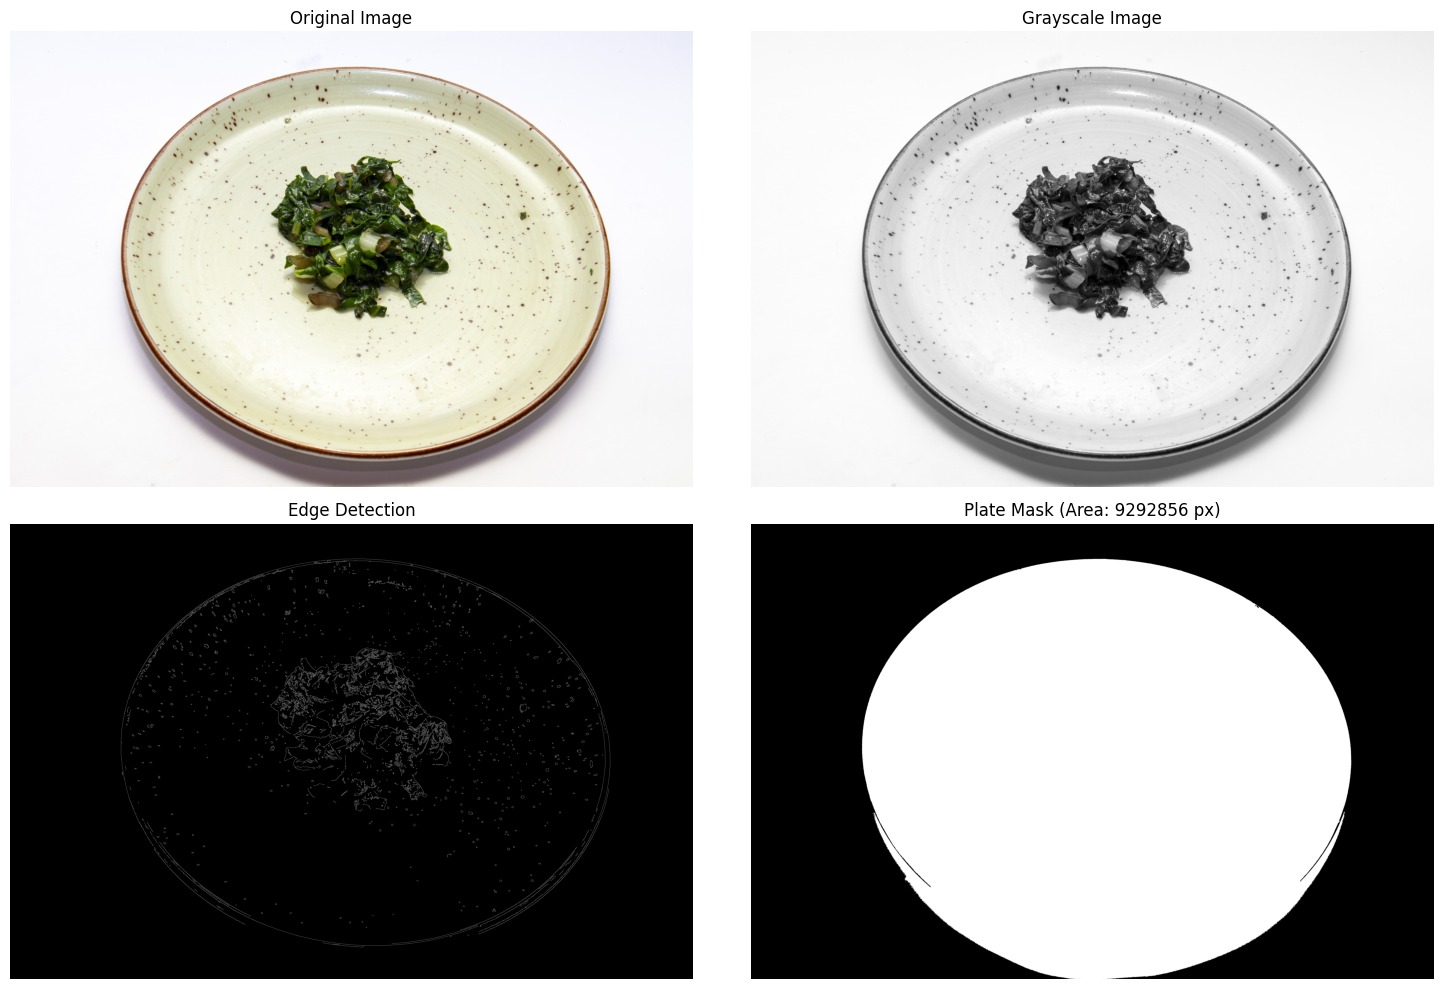

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_plate_detection(image_path):
    # Read and process image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # Edge detection using Canny (for visualization)
    edges = cv2.Canny(blurred, 50, 150)
    
    # Thresholding
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Create visualization
    plt.figure(figsize=(15, 10))
    
    # Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    # Grayscale Image
    plt.subplot(2, 2, 2)
    plt.imshow(gray, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')
    
    # Edge Detection
    plt.subplot(2, 2, 3)
    plt.imshow(edges, cmap='gray')
    plt.title('Edge Detection')
    plt.axis('off')
    
    # Plate Mask
    plt.subplot(2, 2, 4)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(gray)
        cv2.drawContours(mask, [largest_contour], -1, (255), thickness=cv2.FILLED)
        area = cv2.contourArea(largest_contour)
        plt.imshow(mask, cmap='gray')
        plt.title(f'Plate Mask (Area: {area:.0f} px)')
    else:
        plt.imshow(np.zeros_like(gray), cmap='gray')
        plt.title('No Plate Detected')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example usage
visualize_plate_detection('/home/aojwang/data/Dataset/images/Day 7/1000Spinachquotercup.jpg')

In [8]:
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import shutil
import logging
from ultralytics import YOLO

# --- CONFIG ---
YOLO_MODEL_PATH = "/home/aojwang/data/model/model/CarboAI/runs/train/yolo11_food_detection_improved4/weights/best.pt"
IMAGE_DIR = "/home/aojwang/data/MergeDataset/images"
CROP_DIR = "/home/aojwang/data/MergeDataset/cropped_images"
SUPPORTED_IMG_EXTS = ('.jpg', '.JPG')

# ===============================
# 1. Detect Plate Mask and Area
# ===============================
def get_plate_mask_and_area(image):
    """
    Detects the largest contour (assumed to be the plate) and returns
    its binary mask and pixel area.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 100, 200)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, 0

    largest_contour = max(contours, key=cv2.contourArea)
    mask = np.zeros_like(gray)
    cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

    area = cv2.countNonZero(mask)
    return mask, area


# ===============================
# 2. Calculate Food Features
# ===============================
def calculate_food_features(crop_np, bbox, plate_area):
    """
    Calculates food features from a cropped food image.

    Args:
        crop_np (np.ndarray): Cropped food image (RGB).
        bbox (tuple): (x1, y1, x2, y2) coordinates.
        plate_area (int): Area of the plate in pixels.

    Returns:
        dict: Features {food_plate_ratio, aspect_ratio, avg_rgb_intensity}.
    """
    x1, y1, x2, y2 = bbox
    width, height = max(0, x2 - x1), max(0, y2 - y1)
    food_area = width * height
    food_plate_ratio = food_area / plate_area if plate_area > 0 else 0
    aspect_ratio = width / height if height > 0 else 0
    avg_rgb_intensity = tuple(map(float, np.mean(crop_np, axis=(0, 1))))

    return {
        "food_plate_ratio": food_plate_ratio,
        "aspect_ratio": aspect_ratio,
        "avg_rgb_intensity": avg_rgb_intensity
    }


# ===============================
# 3. Detect and Crop
# ===============================
def detect_and_crop(model, image_dir, crop_dir, supported_exts=('.jpg', '.JPG')):
    """
    Detects plate and food items, calculates features, saves crops,
    and returns structured results.
    """
    image_dir = Path(image_dir)
    crop_dir = Path(crop_dir)

    # Clear crop_dir for fresh results
    if crop_dir.exists():
        shutil.rmtree(crop_dir)
    crop_dir.mkdir(parents=True, exist_ok=True)

    feature_records = []

    for img_path in image_dir.glob('*'):
        if img_path.suffix.lower() not in supported_exts:
            continue

        img_name = img_path.name
        image = cv2.imread(str(img_path))
        if image is None:
            print(f"[WARN] Could not read {img_path}")
            continue

        # --- Detect plate ---
        plate_mask, plate_area = get_plate_mask_and_area(image)
        if plate_mask is None or plate_area == 0:
            print(f"[DEBUG] Plate not found in {img_name}")
            continue

        # --- YOLO detection ---
        results = model(str(img_path))
        result = results[0]

        pil_image = Image.open(img_path).convert("RGB")
        save_dir = crop_dir / img_path.stem
        save_dir.mkdir(parents=True, exist_ok=True)

        for i, box in enumerate(result.boxes):
            cls_id = int(box.cls.item())
            label = model.names[cls_id].lower()
            conf = box.conf.item()
            if conf < 0.25:
                continue

            # Bounding box coords
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            # Crop image
            crop_img = pil_image.crop((x1, y1, x2, y2))
            crop_path = save_dir / f"{label}_{i}.jpg"
            crop_img.save(crop_path)

            # Convert crop to numpy
            crop_np = np.array(crop_img)

            # Calculate features
            features = calculate_food_features(crop_np, (x1, y1, x2, y2), plate_area)

            # Record
            feature_records.append({
                "image": img_name,
                "label": label,
                "crop_path": str(crop_path),
                **features
            })

    return feature_records


# ===============================
# 4. Example Run
# ===============================
if __name__ == "__main__":
    logging.getLogger("ultralytics").setLevel(logging.CRITICAL)  # suppress YOLO logs
    model = YOLO(YOLO_MODEL_PATH)

    records = detect_and_crop(model, IMAGE_DIR, CROP_DIR, SUPPORTED_IMG_EXTS)
    print(f"[INFO] Extracted features for {len(records)} detected food items.")
    for r in records[:5]:  # preview first few
        print(r)


[INFO] Extracted features for 3657 detected food items.
{'image': '341LettuceOnions.jpg', 'label': 'onions', 'crop_path': '/home/aojwang/data/MergeDataset/cropped_images/341LettuceOnions/onions_0.jpg', 'food_plate_ratio': 821.78955954323, 'aspect_ratio': 0.8884462151394422, 'avg_rgb_intensity': (160.37442209239774, 127.30637886917701, 140.7034279424405)}
{'image': '341LettuceOnions.jpg', 'label': 'lettuce', 'crop_path': '/home/aojwang/data/MergeDataset/cropped_images/341LettuceOnions/lettuce_1.jpg', 'food_plate_ratio': 1253.7047308319738, 'aspect_ratio': 1.183002481389578, 'avg_rgb_intensity': (186.6538757561602, 190.24736994825125, 143.13044048243313)}
{'image': '1651WholeFishKachumbarithirdCupBrownUgalihalfCup.JPG', 'label': 'brown ugali', 'crop_path': '/home/aojwang/data/MergeDataset/cropped_images/1651WholeFishKachumbarithirdCupBrownUgalihalfCup/brown ugali_0.jpg', 'food_plate_ratio': 2011.132743362832, 'aspect_ratio': 1.0455341506129596, 'avg_rgb_intensity': (143.3991858005732, 11

In [9]:
import pandas as pd
from pathlib import Path
from collections import defaultdict

def parse_nutrition_csv(csv_path, supported_exts=('.jpg', '.JPG')):
    """
    Parses a nutrition CSV file to extract carbohydrate content per food item in each image.

    Expected CSV structure:
    - Column 'ospath' contains image paths or empty cells for continuation rows.
    - Column 'LABELS' contains food names.
    - Column 'CARBOHYDRATES AVAILABLE CARBOHYDRATE CONTENT/ (g)' contains carb values.
    - Each block of rows starting with a .jpg/.JPG path corresponds to one image.

    Args:
        csv_path (str | Path): Path to the CSV file.
        supported_exts (tuple): File extensions treated as valid image entries.

    Returns:
        dict:
            Mapping from image_name (str) → list of dicts:
                {
                    'label': str (lowercase food label),
                    'carb': float (grams of available carbs)
                }
    """
    df = pd.read_csv(csv_path).fillna('')
    nutrition_data = defaultdict(list)
    current_image = None

    # Verify required columns
    required_cols = ['ospath', 'LABELS', 'CARBOHYDRATES AVAILABLE CARBOHYDRATE CONTENT/ (g)']
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"CSV missing required column: {col}")

    for _, row in df.iterrows():
        path = str(row['ospath']).strip()
        label = str(row['LABELS']).strip()

        # If a new image path appears, set it as current_image
        if path.lower().endswith(supported_exts):
            current_image = Path(path).name  # store only the filename

        # Skip if no active image block or no label
        if not current_image or not label:
            continue

        # Parse carbohydrate content
        try:
            carb_value = float(row['CARBOHYDRATES AVAILABLE CARBOHYDRATE CONTENT/ (g)'])
        except (ValueError, TypeError):
            continue  # skip invalid/missing carb values

        # Store lowercase label + carb content
        nutrition_data[current_image].append({
            'label': label.lower(),
            'carb': carb_value
        })

    return nutrition_data


if __name__ == "__main__":
    CSV_FILE = "/home/aojwang/data/MergeDataset/csv_files/found_merged.csv"
    SUPPORTED_IMG_EXTS = ('.jpg', '.JPG')

    nutrition_map = parse_nutrition_csv(CSV_FILE, SUPPORTED_IMG_EXTS)

    print(f"[INFO] Parsed nutrition data for {len(nutrition_map)} images.")
    for img_name, items in list(nutrition_map.items())[:5]:  # preview first 5 images
        print(f"\n📷 {img_name}")
        for item in items:
            print(f"  🍽️ {item['label']} - {item['carb']}g carbs")


[INFO] Parsed nutrition data for 2258 images.

📷 1BirianiLamb.jpg
  🍽️ biryani lamb - 24.0g carbs

📷 2BirianiLamb.jpg
  🍽️ biryani lamb - 48.0g carbs

📷 3BirianiLamb.jpg
  🍽️ biryani lamb - 72.0g carbs

📷 1BreadBacon.jpg
  🍽️ brown bread - 13.0g carbs
  🍽️ bacon - 0.0g carbs

📷 2BreadBacon.jpg
  🍽️ brown bread - 36.0g carbs
  🍽️ bacon - 0.0g carbs


In [23]:
import pandas as pd

def build_dataset(crops, nutrition_lookup):
    """
    Merge YOLO-detected crops with parsed nutrition information.

    Args:
        crops (list of dict):
            Each dict contains:
                - 'image': str, original image filename
                - 'label': str, detected food label
                - 'features': tuple (food_plate_ratio, aspect_ratio, avg_rgb_intensity)  OR
                  separate keys 'food_plate_ratio', 'aspect_ratio', 'avg_rgb_intensity'
                - 'crop_path': str, path to saved cropped image
        nutrition_lookup (dict):
            image_name -> [{'label': str, 'carb': float}, ...]

    Returns:
        pd.DataFrame with:
            image, label, food_plate_ratio, aspect_ratio, avg_rgb_intensity, carb, crop_path
    """
    records = []

    for item in crops:
        image_name = item['image']
        label = item['label'].strip().lower()

        # Handle tuple or individual keys
        if 'features' in item:
            food_plate_ratio, aspect_ratio, avg_rgb_intensity = item['features']
        else:
            food_plate_ratio = item.get('food_plate_ratio', None)
            aspect_ratio = item.get('aspect_ratio', None)
            avg_rgb_intensity = item.get('avg_rgb_intensity', None)

        # If it's a tuple, unpack into separate channels
        if isinstance(avg_rgb_intensity, tuple):
            avg_r, avg_g, avg_b = avg_rgb_intensity
        else:
            avg_r, avg_g, avg_b = (None, None, None)

        crop_path = item['crop_path']

        match = next(
            (x for x in nutrition_lookup.get(image_name, []) if x['label'] == label),
            None
        )

        if match:
            records.append({
                'image': image_name,
                'label': label,
                'food_plate_ratio': food_plate_ratio,
                'aspect_ratio': aspect_ratio,
                'avg_r': avg_r,
                'avg_g': avg_g,
                'avg_b': avg_b,
                'carb': match['carb'],
                'crop_path': crop_path
            })
        # else:
        #     # Debug: show which foods didn't match
        #     print(f"⚠️ No nutrition match for: {image_name} - {label}")

    return pd.DataFrame(records)


# Usage
dataset = build_dataset(records, nutrition_map)
print(f"✅ Dataset created with {len(dataset)} records")
display(dataset.head())
dataset.to_csv("refined_dataset.csv", index=False)


✅ Dataset created with 3402 records


,image,label,food_plate_ratio,aspect_ratio,avg_r,avg_g,avg_b,carb,crop_path
0,341LettuceOnions.jpg,onions,821.789560,0.888446,160.374422,127.306379,140.703428,1.50,/home/aojwang/data/MergeDataset/cropped_images...
1,341LettuceOnions.jpg,lettuce,1253.704731,1.183002,186.653876,190.247370,143.130440,1.20,/home/aojwang/data/MergeDataset/cropped_images...
2,1651WholeFishKachumbarithirdCupBrownUgalihalfC...,brown ugali,2011.132743,1.045534,143.399186,118.336719,57.129991,1.90,/home/aojwang/data/MergeDataset/cropped_images...
3,1651WholeFishKachumbarithirdCupBrownUgalihalfC...,kachumbari,2927.336283,1.215180,143.096610,113.406260,46.757662,0.92,/home/aojwang/data/MergeDataset/cropped_images...
4,1651WholeFishKachumbarithirdCupBrownUgalihalfC...,fish fry,8016.176991,2.665266,135.288731,122.295576,70.902828,126.43,/home/aojwang/data/MergeDataset/cropped_images...


In [28]:
# df['crop_path']
df.columns
# df.head()

Index(['image', 'label', 'area', 'aspect_ratio', 'avg_intensity', 'carb',
       'crop_path'],
      dtype='object')

### Create dataset

In [5]:
import torch
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torchvision import transforms
from PIL import Image
import pandas as pd
import random


# =========================
# Transform Factory
# =========================
def get_base_transform(image_size=(224, 224)):
    """
    Standard preprocessing for model input.
    Args:
        image_size (tuple): Target size (H, W)
    """
    return transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])


def get_augmentation_transforms(image_size=(224, 224)):
    """
    Returns a dictionary of possible augmentation pipelines.
    """
    return {
            "rotation": transforms.Compose([
                transforms.RandomRotation(20),
                transforms.Resize(image_size),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ]),
            "translation": transforms.Compose([
                transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)),
                transforms.Resize(image_size),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ]),
            "hflip": transforms.Compose([
                transforms.RandomHorizontalFlip(p=1.0),
                transforms.Resize(image_size),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ]),
            "vflip": transforms.Compose([
                transforms.RandomVerticalFlip(p=1.0),
                transforms.Resize(image_size),
                transforms.ToTensor(),
                transforms.Normalize([0.485, 0.456, 0.406],
                                     [0.229, 0.224, 0.225])
            ])
    }



# =========================
# Dataset Definition
# =========================
class FoodRegressionDataset(Dataset):
    """
    PyTorch Dataset for food carbohydrate regression using both image crops and tabular features.
    """

    def __init__(self, dataframe, transform=None, augment=False,
                 scaler=None, label_encoder=None, image_size=(224, 224)):
        """
        Args:
            dataframe (pd.DataFrame): Must contain columns:
                ['crop_path', 'label', 'food_plate_ratio', 'aspect_ratio', 'avg_r', 'avg_g', 'avg_b', 'carb']
            transform (callable, optional): Transform to apply to images.
            augment (bool): Whether to apply random augmentations.
            scaler (sklearn Scaler, optional): Fitted scaler for tabular features.
            label_encoder (sklearn LabelEncoder, optional): Fitted label encoder for labels.
            image_size (tuple): Target image size (H, W).
        """
        self.df = dataframe.reset_index(drop=True)
        self.augment = augment
        self.scaler = scaler
        self.label_encoder = label_encoder
        self.image_size = image_size

        # Prepare transforms
        self.base_transform = transform or get_base_transform(image_size)
        self.augmentations = list(get_augmentation_transforms(image_size).values())

        # Tabular features 
        features = self.df[["food_plate_ratio", "aspect_ratio", "avg_r", "avg_g", "avg_b"]]
        self.features = scaler.transform(features) if scaler else features.values

        # Encode labels if provided
        labels = pd.Series(self.df["label"]).str.strip().str.lower().values
        self.labels = label_encoder.transform(labels) if label_encoder else labels


        # Regression targets (carb values)
        self.targets = self.df["carb"].values

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["crop_path"]

        # Load image
        image = Image.open(img_path).convert("RGB")

        # Choose transform
        transform = random.choice(self.augmentations) if self.augment else self.base_transform
        image_tensor = transform(image)

        # Tabular features tensor
        tabular_tensor = torch.tensor(self.features[idx], dtype=torch.float32)

        # Encoded label tensor
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)

        # Regression target tensor
        target_tensor = torch.tensor(self.targets[idx], dtype=torch.float32)

        return {
            "image": image_tensor,
            "tabular": tabular_tensor,
            "label": label_tensor,
            "target": target_tensor,
            "filename": row["image"]
        }


#### Train the Carbohydrate Regression Model


Epoch 1/50


Train loss: 0.5020 | Val loss: 0.3596
Val metrics: MAE=8.251, RMSE=14.015, MAPE=44430580.00%, R2=0.174
Saved best model -> training_output/best_vit_regressor.pth

Epoch 2/50


Train loss: 0.3124 | Val loss: 0.3753
Val metrics: MAE=7.520, RMSE=12.668, MAPE=27832890.00%, R2=0.325

Epoch 3/50


Train loss: 0.2626 | Val loss: 0.2453
Val metrics: MAE=6.036, RMSE=9.964, MAPE=57131456.00%, R2=0.582
Saved best model -> training_output/best_vit_regressor.pth

Epoch 4/50


Train loss: 0.2018 | Val loss: 0.1921
Val metrics: MAE=5.108, RMSE=9.081, MAPE=48268000.00%, R2=0.653
Saved best model -> training_output/best_vit_regressor.pth

Epoch 5/50


...

Train loss: 0.0104 | Val loss: 0.0934
Val metrics: MAE=2.886, RMSE=6.157, MAPE=29834306.00%, R2=0.841

Epoch 48/50


Train loss: 0.0112 | Val loss: 0.0935
Val metrics: MAE=2.870, RMSE=6.197, MAPE=29967504.00%, R2=0.839

Epoch 49/50


Train loss: 0.0099 | Val loss: 0.0933
Val metrics: MAE=2.920, RMSE=6.211, MAPE=29875176.00%, R2=0.838

Epoch 50/50


Train loss: 0.0107 | Val loss: 0.0928
Val metrics: MAE=2.873, RMSE=6.159, MAPE=29950460.00%, R2=0.840



Final validation metrics (best model):
MAE: 2.9410
MSE: 37.0640
RMSE: 6.0880
MAPE: 30225910.00%
R2: 0.8441


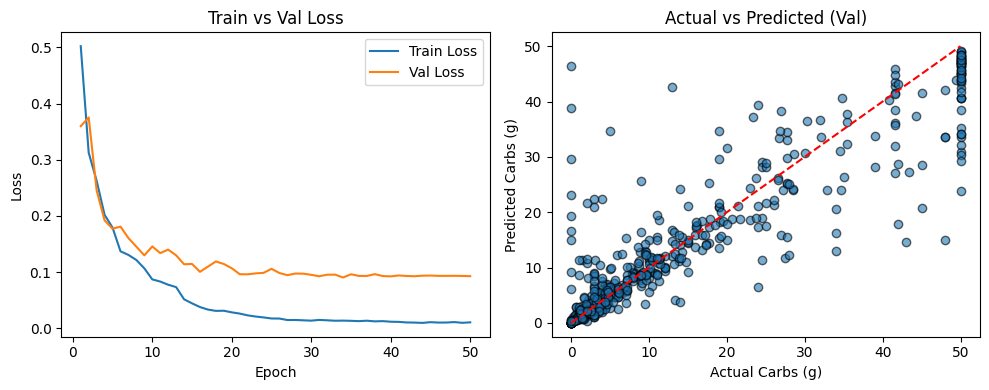

Saved plot -> training_output/training_and_pred_plots.png


In [62]:
# Vit model with carb content capped between 0-50g
import os
import random
import joblib
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision.models.vision_transformer import vit_b_16
from torchvision import transforms
from PIL import Image

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# -------------------------
# Model
# -------------------------
class FoodViTRegressor(nn.Module):
    def __init__(self, tabular_dim=5, vit_pretrained=True, dropout=0.2):
        super().__init__()
        # use torchvision vit_b_16
        self.vit = vit_b_16(pretrained=vit_pretrained)
        self.vit.heads = nn.Identity()  # feature dim = 768

        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(768 + 16, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, img, tabular):
        img_feat = self.vit(img)           # (B, 768)
        tab_feat = self.tabular_net(tabular)  # (B, 16)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        return self.fc(combined).squeeze(1)   # (B,)

# -------------------------
# Utilities: metrics + plotting
# -------------------------
def inverse_log1p(x):
    return np.expm1(x)

def compute_regression_metrics(y_true_raw, y_pred_raw):
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    mse = mean_squared_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true_raw - y_pred_raw) / np.clip(y_true_raw, 1e-6, None))) * 100
    r2 = r2_score(y_true_raw, y_pred_raw)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape, "R2": r2}

# -------------------------
# Training / Validation loops
# -------------------------
def train_one_epoch(model, loader, optimizer, criterion, device, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    n = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        images = batch["image"].to(device)
        tabular = batch["tabular"].to(device)
        targets_log = torch.log1p(batch["target"].to(device))

        optimizer.zero_grad()
        outputs_log = model(images, tabular)
        loss = criterion(outputs_log, targets_log)
        loss.backward()
        if max_grad_norm:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        bs = images.size(0)
        running_loss += loss.item() * bs
        n += bs
    return running_loss / max(1, n)

def validate_and_predict(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n = 0
    preds_log_list = []
    trues_list = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Val", leave=False):
            images = batch["image"].to(device)
            tabular = batch["tabular"].to(device)
            targets = batch["target"].to(device)

            outputs_log = model(images, tabular)
            loss = criterion(outputs_log, torch.log1p(targets))
            bs = images.size(0)
            running_loss += loss.item() * bs
            n += bs

            preds_log_list.append(outputs_log.cpu().numpy())
            trues_list.append(targets.cpu().numpy())

    preds_log = np.concatenate(preds_log_list, axis=0)
    trues = np.concatenate(trues_list, axis=0)
    avg_loss = running_loss / max(1, n)
    preds_raw = inverse_log1p(preds_log)
    return avg_loss, trues, preds_raw

# -------------------------
# Main runner
# -------------------------
def run_training(
    csv_path="refined_dataset.csv",
    tabular_features=["food_plate_ratio", "aspect_ratio", "avg_r", "avg_g", "avg_b"],
    label_col="label",
    target_col="carb",
    test_size=0.2,
    batch_size=32,
    num_epochs=20,
    lr=1e-4,
    weight_decay=1e-5,
    cap_carb=(0.0, 50.0),
    device=None,
    save_dir="output"
):
    os.makedirs(save_dir, exist_ok=True)
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    # load
    df = pd.read_csv(csv_path)

    # clean label strings
    if label_col in df.columns:
        df[label_col] = df[label_col].astype(str).str.strip().str.lower()

    # cap carb values
    if target_col in df.columns:
        df[target_col] = df[target_col].clip(lower=cap_carb[0], upper=cap_carb[1])

    # Fit LabelEncoder on ALL labels (prevents unseen label error)
    label_encoder = None
    if label_col in df.columns:
        all_labels = df[label_col].astype(str).str.strip().str.lower().values
        label_encoder = LabelEncoder().fit(all_labels)
        joblib.dump(label_encoder, os.path.join(save_dir, "label_encoder.pkl"))

    # Split 
    try:
        stratify_col = pd.qcut(df[target_col], q=5, duplicates="drop")
    except Exception:
        stratify_col = None
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=42, stratify=stratify_col)

    # Fit scaler on train only
    scaler = StandardScaler().fit(train_df[tabular_features].values.astype(float))
    joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))

    # Datasets & loaders
    train_ds = FoodRegressionDataset(train_df, transform=None, augment=True, scaler=scaler, label_encoder=label_encoder)
    val_ds = FoodRegressionDataset(val_df, transform=None, augment=False, scaler=scaler, label_encoder=label_encoder)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # Model + optimizer + scheduler
    model = FoodViTRegressor(tabular_dim=len(tabular_features)).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, verbose=True)
    criterion = nn.SmoothL1Loss()

    best_val_loss = float("inf")
    train_losses, val_losses = [], []

    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, max_grad_norm=1.0)
        val_loss, trues_val, preds_val_raw = None, None, None
        val_loss, trues_val, preds_val_raw = validate_and_predict(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # compute metrics on raw preds (already inverse-transformed)
        # clip preds to [0,50] for evaluation/realism
        preds_val_clipped = np.clip(preds_val_raw, cap_carb[0], cap_carb[1])
        metrics = compute_regression_metrics(trues_val, preds_val_clipped)

        print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")
        print(f"Val metrics: MAE={metrics['MAE']:.3f}, RMSE={metrics['RMSE']:.3f}, MAPE={metrics['MAPE']:.2f}%, R2={metrics['R2']:.3f}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_path = os.path.join(save_dir, "best_vit_regressor.pth")
            torch.save(model.state_dict(), best_path)
            print(f"Saved best model -> {best_path}")

    # After training, load best model and compute final predictions/plots
    best_path = os.path.join(save_dir, "best_vit_regressor.pth")
    model.load_state_dict(torch.load(best_path, map_location=device))
    model.to(device)
    _, trues_val, preds_val_raw = validate_and_predict(model, val_loader, criterion, device)

    preds_val_clipped = np.clip(preds_val_raw, cap_carb[0], cap_carb[1])
    final_metrics = compute_regression_metrics(trues_val, preds_val_clipped)
    print("\nFinal validation metrics (best model):")
    for k, v in final_metrics.items():
        if k == "MAPE":
            print(f"{k}: {v:.2f}%")
        else:
            print(f"{k}: {v:.4f}")

    # Plot Loss Curves
    epochs = np.arange(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Train vs Val Loss")
    plt.legend()

    # Plot Actual vs Predicted (validation)
    plt.subplot(1, 2, 2)
    plt.scatter(trues_val, preds_val_clipped, alpha=0.6, edgecolors="k")
    mx = max(trues_val.max(), preds_val_clipped.max())
    mn = min(trues_val.min(), preds_val_clipped.min())
    plt.plot([mn, mx], [mn, mx], "r--")
    plt.xlabel("Actual Carbs (g)")
    plt.ylabel("Predicted Carbs (g)")
    plt.title("Actual vs Predicted (Val)")
    plt.tight_layout()
    plot_path = os.path.join(save_dir, "training_and_pred_plots.png")
    plt.savefig(plot_path)
    plt.show()
    print(f"Saved plot -> {plot_path}")

    return {
        "model": model,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "history": {"train_losses": train_losses, "val_losses": val_losses},
        "final_metrics": final_metrics
    }

# -------------------------
# Entry point
# -------------------------
if __name__ == "__main__":
    out = run_training(
        csv_path="refined_dataset.csv",
        tabular_features=["food_plate_ratio", "aspect_ratio", "avg_r", "avg_g", "avg_b"],
        label_col="label",
        target_col="carb",
        test_size=0.2,
        batch_size=32,
        num_epochs=50,
        lr=1e-4,
        weight_decay=1e-5,
        cap_carb=(0.0, 50.0),
        save_dir="training_output"
    )


/opt/dlami/nvme/aojwang/torchenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/dlami/nvme/aojwang/torchenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/dlami/nvme/aojwang/torchenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/opt/dlami/nvme/aojwang/torchenv/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/dlami/nvme/aojwang/torchenv/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'we

Starting training with 2721 train, 340 val, 341 test samples
Target range: 0.0 to 50.0g carbs

Epoch 1/50


Train loss: 0.5488 | Val loss: 0.3743
Validation metrics:
  MAE: 8.0774
  MSE: 188.1534
  RMSE: 13.7169
  MAPE: 22159340.0000%
  R2: 0.1662
Saved best model -> training_output/best_vit_regressor.pth

Epoch 2/50


Train loss: 0.3854 | Val loss: 0.3209
Validation metrics:
  MAE: 7.5158
  MSE: 160.7399
  RMSE: 12.6783
  MAPE: 24987940.0000%
  R2: 0.2876
Saved best model -> training_output/best_vit_regressor.pth

Epoch 3/50


Train loss: 0.3078 | Val loss: 0.2638
Validation metrics:
  MAE: 6.4475
  MSE: 119.4697
  RMSE: 10.9302
  MAPE: 27279054.0000%
  R2: 0.4705
Saved best model -> training_output/best_vit_regressor.pth

Epoch 4/50


...

Train loss: 0.0107 | Val loss: 0.0982
Validation metrics:
  MAE: 3.1119
  MSE: 46.8645
  RMSE: 6.8458
  MAPE: 24725954.0000%
  R2: 0.7923

Epoch 49/50


Train loss: 0.0107 | Val loss: 0.0989
Validation metrics:
  MAE: 3.0853
  MSE: 45.8052
  RMSE: 6.7680
  MAPE: 24027336.0000%
  R2: 0.7970

Epoch 50/50


/tmp/ipykernel_13285/1861309995.py:263: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=device))


Train loss: 0.0105 | Val loss: 0.0993
Validation metrics:
  MAE: 3.2020
  MSE: 47.2150
  RMSE: 6.8713
  MAPE: 23788906.0000%
  R2: 0.7908

Training complete. Evaluating on test set...



Test set metrics (best model):
  MAE: 3.0982
  MSE: 36.3437
  RMSE: 6.0286
  MAPE: 20566156.0000%
  R2: 0.8545


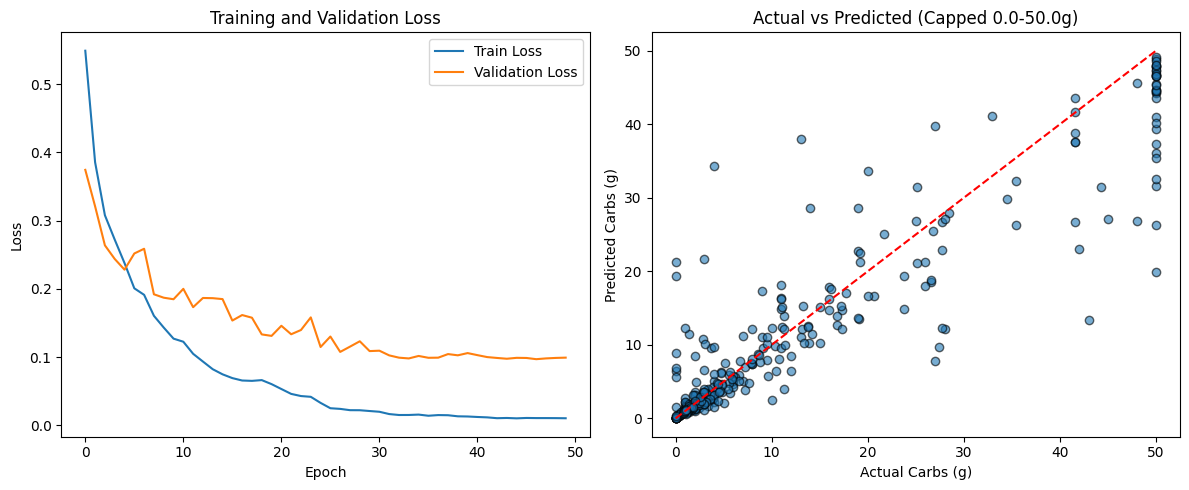

In [8]:
# Vit model with carb content capped between 0-50g + huberloss+ augmentation
import os
import random
import joblib
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision.models.vision_transformer import vit_b_16
from torchvision import transforms
from PIL import Image

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -------------------------
# Model
# -------------------------
class FoodViTRegressor(nn.Module):
    def __init__(self, tabular_dim=5, vit_pretrained=True, dropout=0.2):
        super().__init__()
        # use torchvision vit_b_16
        self.vit = vit_b_16(pretrained=vit_pretrained)
        self.vit.heads = nn.Identity()  # feature dim = 768

        self.tabular_net = nn.Sequential(
            nn.Linear(tabular_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(768 + 16, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, img, tabular):
        img_feat = self.vit(img)           # (B, 768)
        tab_feat = self.tabular_net(tabular)  # (B, 16)
        combined = torch.cat([img_feat, tab_feat], dim=1)
        return self.fc(combined).squeeze(1)   # (B,)

# -------------------------
# Utilities: metrics + plotting
# -------------------------
def inverse_log1p(x):
    return np.expm1(x)

def compute_regression_metrics(y_true_raw, y_pred_raw):
    mae = mean_absolute_error(y_true_raw, y_pred_raw)
    mse = mean_squared_error(y_true_raw, y_pred_raw)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true_raw - y_pred_raw) / np.clip(y_true_raw, 1e-6, None))) * 100
    r2 = r2_score(y_true_raw, y_pred_raw)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape, "R2": r2}

def plot_metrics(history, trues, preds, cap_carb, save_path=None):
    """Plot training metrics and predictions"""
    plt.figure(figsize=(12, 5))
    
    # Plot loss curves
    plt.subplot(1, 2, 1)
    plt.plot(history['train_losses'], label='Train Loss')
    plt.plot(history['val_losses'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    # Plot actual vs predicted
    plt.subplot(1, 2, 2)
    plt.scatter(trues, preds, alpha=0.6, edgecolors='k')
    mx = max(trues.max(), preds.max())
    mn = min(trues.min(), preds.min())
    plt.plot([mn, mx], [mn, mx], 'r--')
    plt.xlabel('Actual Carbs (g)')
    plt.ylabel('Predicted Carbs (g)')
    plt.title(f'Actual vs Predicted (Capped {cap_carb[0]}-{cap_carb[1]}g)')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.show()

# -------------------------
# Training / Validation loops
# -------------------------
def train_one_epoch(model, loader, optimizer, criterion, device, max_grad_norm=1.0):
    model.train()
    running_loss = 0.0
    n = 0
    for batch in tqdm(loader, desc="Train", leave=False):
        images = batch["image"].to(device)
        tabular = batch["tabular"].to(device)
        targets_log = torch.log1p(batch["target"].to(device))

        optimizer.zero_grad()
        outputs_log = model(images, tabular)
        loss = criterion(outputs_log, targets_log)
        loss.backward()
        if max_grad_norm:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()

        bs = images.size(0)
        running_loss += loss.item() * bs
        n += bs
    return running_loss / max(1, n)

def evaluate_model(model, loader, criterion, device, cap_carb=(0, 50)):
    model.eval()
    running_loss = 0.0
    n = 0
    preds_log_list = []
    trues_list = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluation", leave=False):
            images = batch["image"].to(device)
            tabular = batch["tabular"].to(device)
            targets = batch["target"].to(device)

            outputs_log = model(images, tabular)
            loss = criterion(outputs_log, torch.log1p(targets))
            bs = images.size(0)
            running_loss += loss.item() * bs
            n += bs

            preds_log_list.append(outputs_log.cpu().numpy())
            trues_list.append(targets.cpu().numpy())

    preds_log = np.concatenate(preds_log_list, axis=0)
    trues = np.concatenate(trues_list, axis=0)
    avg_loss = running_loss / max(1, n)
    preds_raw = inverse_log1p(preds_log)
    preds_clipped = np.clip(preds_raw, cap_carb[0], cap_carb[1])
    
    return {
        "loss": avg_loss,
        "trues": trues,
        "preds": preds_clipped,
        "metrics": compute_regression_metrics(trues, preds_clipped)
    }

# -------------------------
# Main runner
# -------------------------
def run_training(csv_path="refined_dataset.csv",tabular_features=["food_plate_ratio", "aspect_ratio", "avg_r", "avg_g", "avg_b"],label_col="label",target_col="carb",batch_size=32,num_epochs=50,lr=1e-4,weight_decay=1e-5,cap_carb=(0.0, 50.0),device=None,save_dir="output"):
    os.makedirs(save_dir, exist_ok=True)
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))

    # Load and preprocess data
    df = pd.read_csv(csv_path)
    
    # Clean label strings
    if label_col in df.columns:
        df[label_col] = df[label_col].astype(str).str.strip().str.lower()
    
    # Cap carb values
    if target_col in df.columns:
        df[target_col] = df[target_col].clip(lower=cap_carb[0], upper=cap_carb[1])

    # Fit LabelEncoder on ALL labels
    label_encoder = None
    if label_col in df.columns:
        all_labels = df[label_col].astype(str).str.strip().str.lower().values
        label_encoder = LabelEncoder().fit(all_labels)
        joblib.dump(label_encoder, os.path.join(save_dir, "label_encoder.pkl"))

    # Split data into train (80%), validation (10%), and test (10%)
    try:
        stratify_col = pd.qcut(df[target_col], q=5, duplicates="drop")
    except Exception:
        stratify_col = None
    
    # First split: 80% train, 20% temp
    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=stratify_col)
    
    # Second split: 10% validation, 10% test (from the 20% temp)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=stratify_col[temp_df.index] if stratify_col is not None else None)

    # Fit scaler on train only
    scaler = StandardScaler().fit(train_df[tabular_features].values.astype(float))
    joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))

    # Create datasets
    train_ds = FoodRegressionDataset(train_df, transform=None, augment=True, scaler=scaler, label_encoder=label_encoder)
    val_ds = FoodRegressionDataset(val_df, transform=None, augment=False, scaler=scaler, label_encoder=label_encoder)
    test_ds = FoodRegressionDataset(test_df, transform=None, augment=False, scaler=scaler, label_encoder=label_encoder)

    # Create data loaders
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    # Initialize model, optimizer, and scheduler
    model = FoodViTRegressor(tabular_dim=len(tabular_features)).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, verbose=True)
    criterion = nn.HuberLoss()

    # Training loop
    best_val_loss = float("inf")
    train_losses, val_losses = [], []
    
    print(f"Starting training with {len(train_df)} train, {len(val_df)} val, {len(test_df)} test samples")
    print(f"Target range: {cap_carb[0]} to {cap_carb[1]}g carbs")

    for epoch in range(1, num_epochs + 1):
        print(f"\nEpoch {epoch}/{num_epochs}")
        
        # Training
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        
        # Validation
        val_results = evaluate_model(model, val_loader, criterion, device, cap_carb)
        val_losses.append(val_results["loss"])
        
        # Print metrics
        print(f"Train loss: {train_loss:.4f} | Val loss: {val_results['loss']:.4f}")
        print("Validation metrics:")
        for k, v in val_results["metrics"].items():
            print(f"  {k}: {v:.4f}" + ("%" if k == "MAPE" else ""))
        
        # Update scheduler and save best model
        scheduler.step(val_results["loss"])
        
        if val_results["loss"] < best_val_loss:
            best_val_loss = val_results["loss"]
            best_path = os.path.join(save_dir, "best_vit_regressor.pth")
            torch.save(model.state_dict(), best_path)
            print(f"Saved best model -> {best_path}")

    # Load best model and evaluate on test set
    print("\nTraining complete. Evaluating on test set...")
    model.load_state_dict(torch.load(best_path, map_location=device))
    test_results = evaluate_model(model, test_loader, criterion, device, cap_carb)
    
    # Print final metrics
    print("\nTest set metrics (best model):")
    for k, v in test_results["metrics"].items():
        print(f"  {k}: {v:.4f}" + ("%" if k == "MAPE" else ""))
    
    # Plot training curves and predictions
    plot_metrics({"train_losses": train_losses, "val_losses": val_losses},test_results["trues"],test_results["preds"],cap_carb,save_path=os.path.join(save_dir, "training_and_pred_plots.png"))

    return {
        "model": model,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "history": {"train_losses": train_losses, "val_losses": val_losses},
        "val_metrics": val_results["metrics"],
        "test_metrics": test_results["metrics"]
    }

# -------------------------
# Entry point
# -------------------------
if __name__ == "__main__":
    out = run_training(
        csv_path="refined_dataset.csv",
        tabular_features=["food_plate_ratio", "aspect_ratio", "avg_r", "avg_g", "avg_b"],
        label_col="label",
        target_col="carb",
        batch_size=32,
        num_epochs=50,
        lr=1e-4,
        weight_decay=1e-5,
        cap_carb=(0.0, 50.0),
        save_dir="training_output"
    )

In [76]:
df = pd.read_csv("refined_dataset.csv")
df.columns

Index(['image', 'label', 'food_plate_ratio', 'aspect_ratio', 'avg_r', 'avg_g',
       'avg_b', 'carb', 'crop_path'],
      dtype='object')

In [ ]:
torch.cuda.empty_cache()
!nvidia-smi


📅 Epoch 1/50


Validating: 100%|████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:03<00:00,  4.90it/s]


Train Loss: 0.8547 | Val Loss: 0.3141
✅ Best model saved.

📅 Epoch 2/50


Validating: 100%|████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:03<00:00,  4.95it/s]


Train Loss: 0.3013 | Val Loss: 0.2200
✅ Best model saved.

📅 Epoch 3/50


...

Train Loss: 0.0525 | Val Loss: 0.0865

📅 Epoch 49/50


Validating: 100%|████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:03<00:00,  5.02it/s]


Train Loss: 0.0630 | Val Loss: 0.0914

📅 Epoch 50/50


Validating: 100%|████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:03<00:00,  4.97it/s]


Train Loss: 0.0520 | Val Loss: 0.0845
✅ Best model saved.


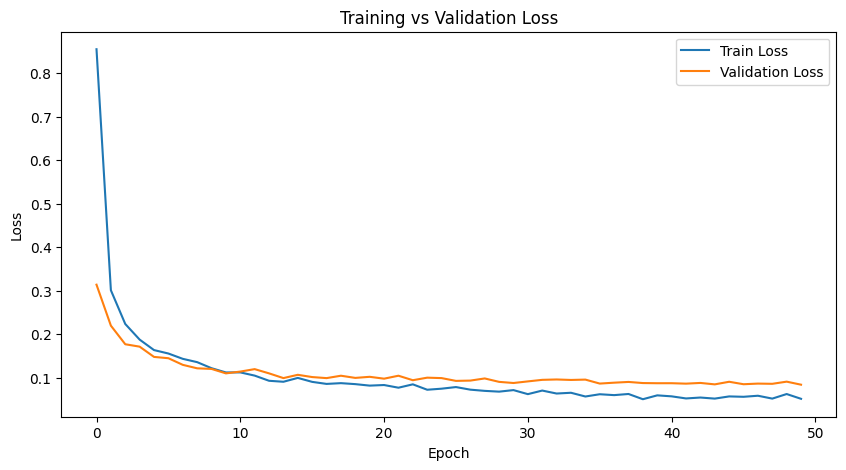

/tmp/ipykernel_13285/870444527.py:208: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("refined_efficientnet_b0.pth"))
Evaluating: 100%|██████


📊 Evaluation Metrics:
MAE: 3.36
MSE: 40.76
RMSE: 6.38
R² Score: 0.83
MAPE: 9234820.00%


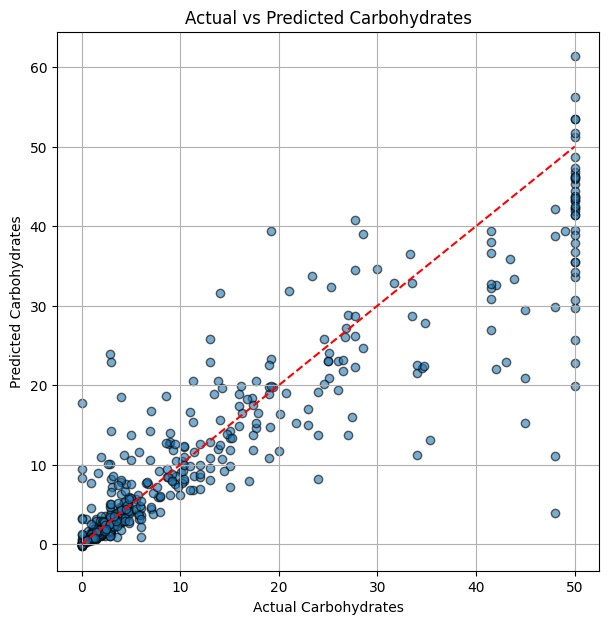

Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:03<00:00,  4.65it/s]



📊 Evaluation Metrics:
MAE: 3.29
MSE: 46.99
RMSE: 6.86
R² Score: 0.81
MAPE: 13224280.00%


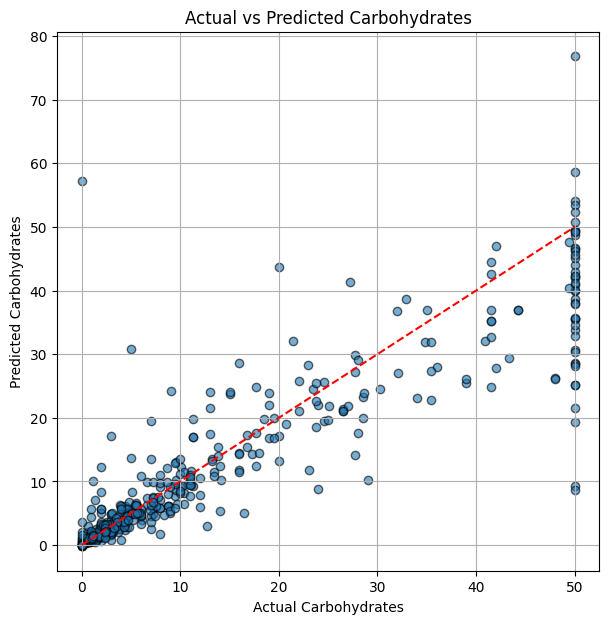


🔍 Sample Predictions:
Image: 1548NjahiWhiteRiceSpinach.JPG | Actual: 4.75 | Predicted: 4.72
Image: 644BrownRice1cup.jpg | Actual: 14.16 | Predicted: 10.27
Image: 1755WhiteRiceWhiteChapatiquoterBeefstew.jpg | Actual: 6.00 | Predicted: 3.28
Image: 1165MincedMeatWhiteChapati1andhalfCabbage.JPG | Actual: 1.20 | Predicted: 1.44
Image: 1018Cabbage.jpg | Actual: 3.85 | Predicted: 2.57
Image: 837WhiteChapati1ButterBeans.jpg | Actual: 11.31 | Predicted: 19.74
Image: 115Pawpawquotercup.jpg | Actual: 0.33 | Predicted: 0.27
Image: 1118BrownRiceFriedEggs.jpg | Actual: 4.00 | Predicted: 5.89
Image: 1686BeefSausageChips.JPG | Actual: 7.20 | Predicted: 7.60
Image: 1WMelon.jpg | Actual: 3.00 | Predicted: 0.85


In [6]:
# EfficientNet model with selective augmentations + HuberLoss + cap 0g-50g + test split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

# ---------------------------
# 1. Model Definition
# ---------------------------
class CarbEstimator(nn.Module):
    def __init__(self, num_extra_features=5): 
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.backbone = nn.Sequential(
            *list(backbone.children())[:-2],
            nn.AdaptiveAvgPool2d(1)
        )
        self.feature_dim = 1280

        self.extra_feature_processor = nn.Sequential(
            nn.Linear(num_extra_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim + 64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, extra_features):
        img_features = self.backbone(image).flatten(1)
        tabular_features = self.extra_feature_processor(extra_features)
        x = torch.cat([img_features, tabular_features], dim=1)
        return self.regressor(x).squeeze()

# ---------------------------
# 2. Training Functions
# ---------------------------
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="Training"):
        image = batch["image"].to(device)
        tabular = batch["tabular"].to(device)
        target = torch.log1p(batch["target"]).to(device)  # log1p for stability

        optimizer.zero_grad()
        output = model(image, tabular)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            image = batch["image"].to(device)
            tabular = batch["tabular"].to(device)
            target = torch.log1p(batch["target"]).to(device)

            output = model(image, tabular)
            loss = criterion(output, target)
            total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_predictions(model, dataloader, device, show_examples=False, n_examples=10):
    model.eval()
    preds, trues, filenames = [], [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            image = batch["image"].to(device)
            tabular = batch["tabular"].to(device)
            target = batch["target"].cpu().numpy()

            output = model(image, tabular).cpu().numpy()
            preds.extend(np.expm1(output))  # reverse log1p
            trues.extend(target)
            filenames.extend(batch["filename"])

    preds = np.array(preds)
    trues = np.array(trues)

    # Metrics
    mae = mean_absolute_error(trues, preds)
    mse = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(trues, preds)
    mape = np.mean(np.abs((trues - preds) / np.clip(trues, 1e-6, None))) * 100

    print(f"\n📊 Evaluation Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"MAPE: {mape:.2f}%")

    # Scatter Plot
    plt.figure(figsize=(7, 7))
    plt.scatter(trues, preds, alpha=0.6, edgecolors='k')
    plt.plot([min(trues), max(trues)], [min(trues), max(trues)], 'r--')
    plt.xlabel('Actual Carbohydrates')
    plt.ylabel('Predicted Carbohydrates')
    plt.title('Actual vs Predicted Carbohydrates')
    plt.grid(True)
    plt.savefig("actual_vs_predicted.png")
    plt.show()

    # Show some examples
    if show_examples:
        print("\n🔍 Sample Predictions:")
        indices = random.sample(range(len(preds)), min(n_examples, len(preds)))
        for i in indices:
            print(f"Image: {filenames[i]} | Actual: {trues[i]:.2f} | Predicted: {preds[i]:.2f}")

# ---------------------------
# 3. Main Training Routine
# ---------------------------
def run_training():
    df = pd.read_csv("/home/aojwang/data/model/model/CarboAI/refined_dataset.csv")

    # Clean labels
    df["label"] = df["label"].str.strip().str.lower()
    df["carb"] = df["carb"].clip(lower=0, upper=50)

    # Fit encoders/scalers
    label_encoder = LabelEncoder().fit(df["label"])
    scaler = StandardScaler().fit(df[["food_plate_ratio", "aspect_ratio", "avg_r", "avg_g", "avg_b"]])

    # Train/Val/Test split
    train_df, temp_df = train_test_split(df,test_size=0.3,random_state=42,stratify=pd.qcut(df["carb"], q=5, duplicates="drop"))
    val_df, test_df = train_test_split(temp_df,test_size=0.5,random_state=42,stratify=pd.qcut(temp_df["carb"], q=5, duplicates="drop"))

    # Datasets
    train_ds = FoodRegressionDataset(train_df, augment=True, scaler=scaler, label_encoder=label_encoder)
    val_ds = FoodRegressionDataset(val_df, augment=False, scaler=scaler, label_encoder=label_encoder)
    test_ds = FoodRegressionDataset(test_df, augment=False, scaler=scaler, label_encoder=label_encoder)

    # Loaders
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CarbEstimator(num_extra_features=5).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = nn.HuberLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

    # Training loop
    best_val_loss = float("inf")
    train_losses, val_losses = [], []

    for epoch in range(50):
        print(f"\n📅 Epoch {epoch + 1}/50")
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "refined_efficientnet_b0.pth")
            print("✅ Best model saved.")

    # Plot loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.savefig("training_curve.png")
    plt.show()

    return model, val_loader, test_loader, device


# ---------------------------
# 4. Run Everything
# ---------------------------
model, val_loader, test_loader, device = run_training()
model.load_state_dict(torch.load("refined_efficientnet_b0.pth"))

# Validate results
evaluate_predictions(model, val_loader, device)

# Test results + 10 sample predictions
evaluate_predictions(model, test_loader, device, show_examples=True, n_examples=10)



📅 Epoch 1/50


Validating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  4.90it/s]


Train Loss: 0.5982 | Val Loss: 0.2925
✅ Best model saved.

📅 Epoch 2/50


Validating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  4.88it/s]


Train Loss: 0.2981 | Val Loss: 0.2020
✅ Best model saved.

📅 Epoch 3/50


...

Train Loss: 0.0637 | Val Loss: 0.0904
✅ Best model saved.

📅 Epoch 49/50


Validating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  4.84it/s]


Train Loss: 0.0686 | Val Loss: 0.0951

📅 Epoch 50/50


Validating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  4.89it/s]


Train Loss: 0.0668 | Val Loss: 0.0936


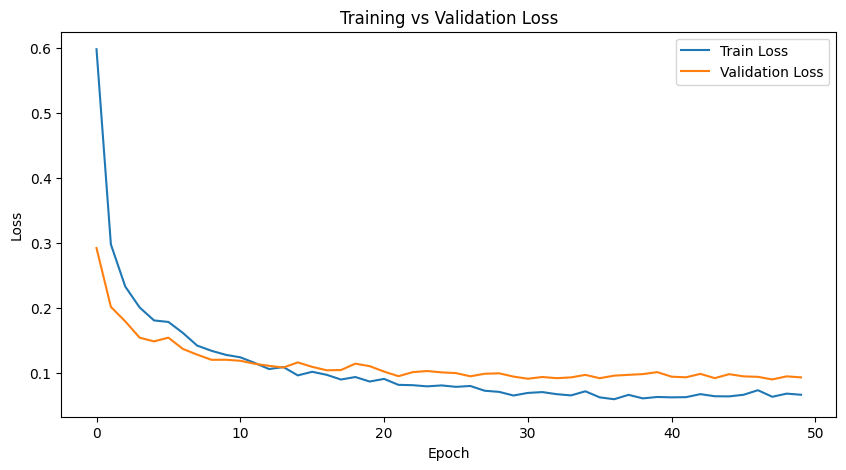

Evaluating: 100%|███████████████████████████████| 22/22 [00:04<00:00,  4.82it/s]



📊 Evaluation Metrics:
MAE: 3.77
MSE: 53.49
RMSE: 7.31
R² Score: 0.78
MAPE: 24536934.00%


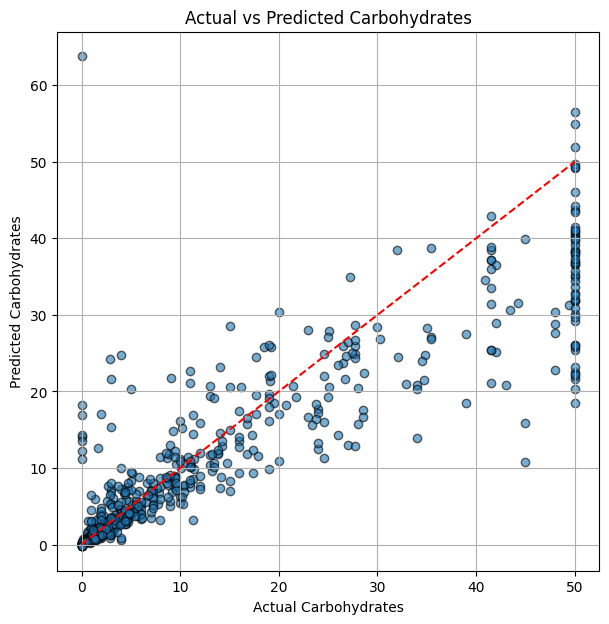

In [63]:
# EfficientNet model with augmentations and cap 0-50g
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

# ---------------------------
# 1. Model Definition
# ---------------------------
class CarbEstimator(nn.Module):
    def __init__(self, num_extra_features=5): 
        super().__init__()
        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.backbone = nn.Sequential(
            *list(backbone.children())[:-2],
            nn.AdaptiveAvgPool2d(1)
        )
        self.feature_dim = 1280

        self.extra_feature_processor = nn.Sequential(
            nn.Linear(num_extra_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.feature_dim + 64, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, image, extra_features):
        img_features = self.backbone(image).flatten(1)
        tabular_features = self.extra_feature_processor(extra_features)
        x = torch.cat([img_features, tabular_features], dim=1)
        return self.regressor(x).squeeze()

# ---------------------------
# 2. Training Functions
# ---------------------------
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in tqdm(dataloader, desc="Training"):
        image = batch["image"].to(device)
        tabular = batch["tabular"].to(device)
        target = torch.log1p(batch["target"]).to(device)  # log1p for stability

        optimizer.zero_grad()
        output = model(image, tabular)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            image = batch["image"].to(device)
            tabular = batch["tabular"].to(device)
            target = torch.log1p(batch["target"]).to(device)

            output = model(image, tabular)
            loss = criterion(output, target)
            total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_predictions(model, dataloader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            image = batch["image"].to(device)
            tabular = batch["tabular"].to(device)
            target = batch["target"].cpu().numpy()

            output = model(image, tabular).cpu().numpy()
            preds.extend(np.expm1(output))  # reverse log1p
            trues.extend(target)

    preds = np.array(preds)
    trues = np.array(trues)

    mae = mean_absolute_error(trues, preds)
    mse = mean_squared_error(trues, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(trues, preds)
    mape = np.mean(np.abs((trues - preds) / np.clip(trues, 1e-6, None))) * 100

    print(f"\n📊 Evaluation Metrics:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"MAPE: {mape:.2f}%")

    plt.figure(figsize=(7, 7))
    plt.scatter(trues, preds, alpha=0.6, edgecolors='k')
    plt.plot([min(trues), max(trues)], [min(trues), max(trues)], 'r--')
    plt.xlabel('Actual Carbohydrates')
    plt.ylabel('Predicted Carbohydrates')
    plt.title('Actual vs Predicted Carbohydrates')
    plt.grid(True)
    plt.savefig("actual_vs_predicted.png")
    plt.show()

# ---------------------------
# 3. Main Training Routine
# ---------------------------
def run_training():
    df = pd.read_csv("/home/aojwang/data/model/model/CarboAI/refined_dataset.csv")

    # Clean labels
    df["label"] = df["label"].str.strip().str.lower()

    # Cap carb values to [0, 50]
    df["carb"] = df["carb"].clip(lower=0, upper=50)

    # Fit encoders/scalers
    label_encoder = LabelEncoder().fit(df["label"])
    scaler = StandardScaler().fit(df[["food_plate_ratio", "aspect_ratio", "avg_r", "avg_g", "avg_b"]])

    # Split dataset
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=pd.qcut(df["carb"], q=5, duplicates="drop")
    )

    # Create datasets
    train_ds = FoodRegressionDataset(train_df, augment=True, scaler=scaler, label_encoder=label_encoder)
    val_ds = FoodRegressionDataset(val_df, augment=False, scaler=scaler, label_encoder=label_encoder)

    # Loaders
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = CarbEstimator(num_extra_features=5).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    criterion = nn.HuberLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)

    # Training loop
    best_val_loss = float("inf")
    train_losses, val_losses = [], []

    for epoch in range(50):
        print(f"\n📅 Epoch {epoch + 1}/50")
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "refined_efficientnet_b0.pth")
            print("✅ Best model saved.")

    # Plot loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.savefig("training_curve.png")
    plt.show()

    return model, val_loader, device


# ---------------------------
# 4. Run Everything
# ---------------------------
model, val_loader, device = run_training()
model.load_state_dict(torch.load("refined_efficientnet_b0.pth"))
evaluate_predictions(model, val_loader, device)


In [ ]:
import pandas as pd

df =  pd.read_csv('refined_dataset.csv')
target_col = 'carb'
df.columns
print("Target variable statistics:")
print(df[target_col].describe())
print(f"\nNumber of zero values: {(df[target_col] == 0).sum()}")
print(f"Negative values: {(df[target_col] < 0).sum()}")

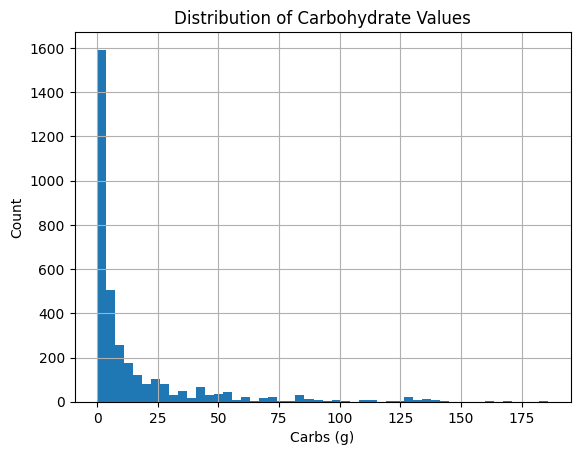

In [51]:
df["carb"].hist(bins=50)
plt.title("Distribution of Carbohydrate Values")
plt.xlabel("Carbs (g)")
plt.ylabel("Count")
plt.show()


# TODO
1. Augmentation test
2. Background removal

# Improvements on the regression model dataset
1. Log-transform the target (carb)-To reduce skew and stabilize variance
2. Normalize tabular features (area, intensity, aspect ratio)-This improves convergence
3. Use a smoother loss like SmoothL1Loss-This is less sensitive to outliers than MSELoss
# Experiments:
- https://pmc.ncbi.nlm.nih.gov/articles/PMC11887021/
- https://arxiv.org/html/2405.16478v1
- https://onlinelibrary.wiley.com/doi/10.1155/2023/6612302